# TASK #1: PROJECT OVERVIEW

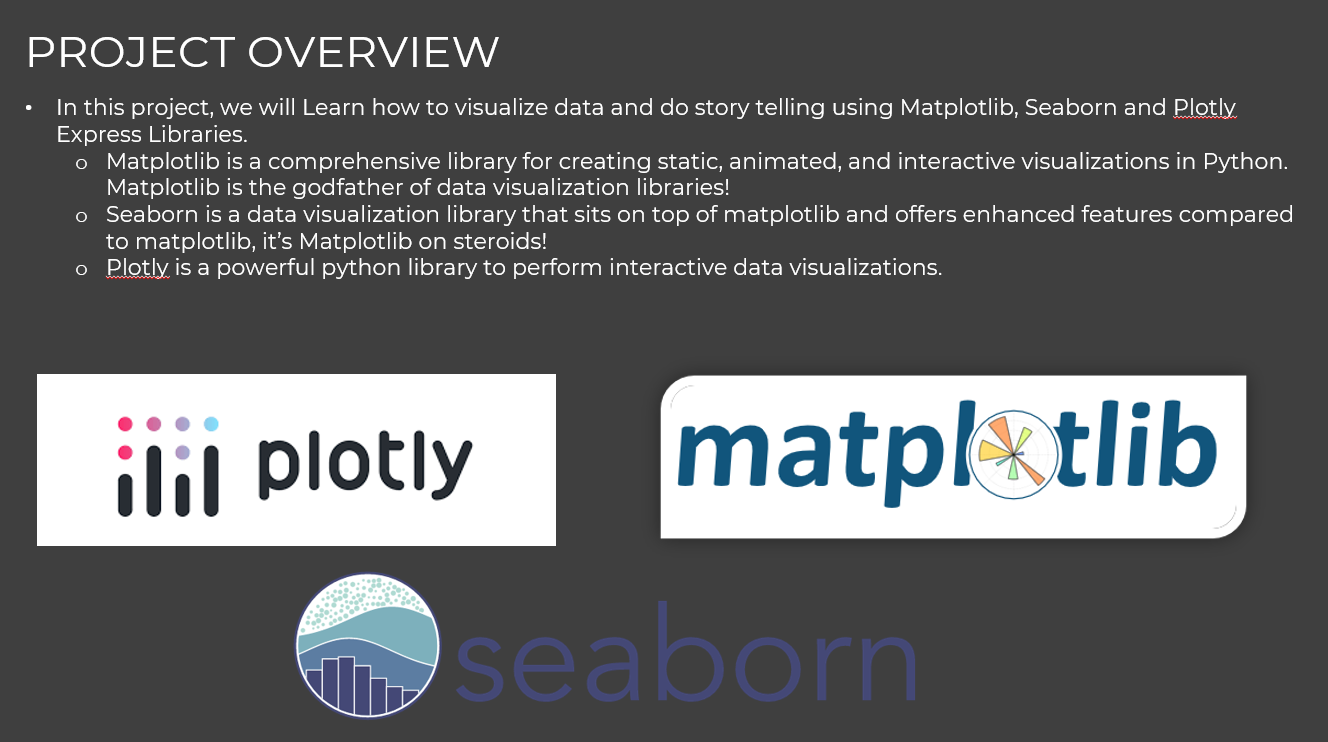

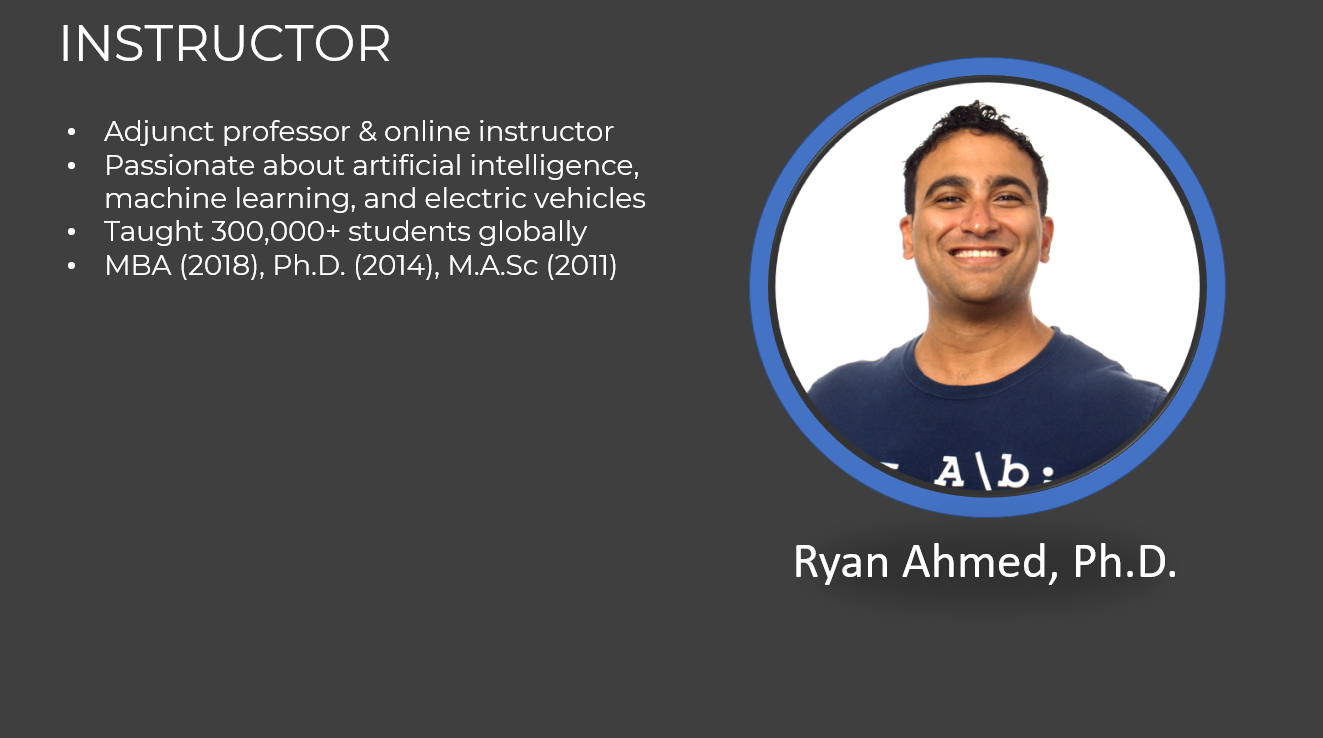

# TASK #2: IMPORT DATASETS AND LIBRARIES

In [1]:
# The World Happiness Report determines the state of global happiness. 
# The happiness scores and rankings data has been collected by asking individuals to rank their life.
# Ranking ranges from 0 (worst possible life) to 10 (best possible life). 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

from jupyterthemes import jtplot
jtplot.style(theme = 'monokai', context = 'notebook', ticks = True, grid = False)

In [ ]:
# Import csv file into pandas dataframe
happy_df = pd.read_csv('happiness_report.csv')

In [ ]:
# print the first 5 rows of the dataframe
happy_df.head()

**PRACTICE OPPORTUNITY #1 [OPTIONAL]:** 
- **Select 2 countries from the dataframe and explore scores. Perform sanity check.**

# TASK #3: PERFORM EXPLORATORY DATA ANALYSIS

In [ ]:
# Check the number of non-null values in the dataframe
happy_df.info()

In [ ]:
# Check Null values
happy_df.isnull().sum()

In [ ]:
# Obtain the Statistical summary of the dataframe
happy_df.describe()

In [ ]:
# check the number of duplicated entries in the dataframe
happy_df.duplicated().sum() # since there are no duplicates, no further action is required

**PRACTICE OPPORTUNITY #2 [OPTIONAL]:** 
- **Which country has the maximum happiness score? What is the perception of corruption in this country?**

# TASK #4: PERFORM DATA VISUALIZATION: PAIRPLOT & SCATTERMATRIX

In [ ]:
# A scatterplot matrix is a matrix associated to n numerical arrays (data variables), $X_1,X_2,…,X_n$ , of the same length. 
# The cell (i,j) of such a matrix displays the scatter plot of the variable Xi versus Xj.
# Here we show the Plotly Express function px.scatter_matrix to plot the scatter matrix for the columns of the dataframe. By default, all columns are considered.

# Note:
# Positive correlation between GDP and score 
# Positive correlation between Social Support and score 


fig = px.scatter_matrix(happy_df[['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']], width = 1500, height = 1500)
fig.show()

In [ ]:
# Alternatively, you can use Seaborn to plot the pairplots as follows (Note that the plot is no longer interactive): 
fig = plt.figure(figsize = (20,20))
sns.pairplot(happy_df[['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 
    'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']])

# Positive correlation between GDP and score 
# Positive correlation between Social Support and score 


# TASK #5: PERFORM DATA VISUALIZATION: DISTPLOT & CORRELATION MATRIX

In [ ]:
# distplot combines the matplotlib.hist function with seaborn kdeplot()

columns = ['Score','GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption']

plt.figure(figsize = (20, 50))
for i in range(len(columns)):
  plt.subplot(8, 2, i+1)
  sns.distplot(happy_df[columns[i]], color = 'g');
  plt.title(columns[i])

plt.tight_layout()

In [ ]:
fig = px.imshow(happy_df.corr())
fig.show()

In [ ]:
# Get the correlation matrix
corr_matrix = happy_df.corr()
corr_matrix
sns.heatmap(corr_matrix, annot = True)

# TASK #6: PERFORM DATA VISUALIZATION: SCATTERPLOTS AND BUBBLE CHARTS

In [ ]:
# Plot the relationship between score, GDP and region
fig = px.scatter(happy_df, x = 'GDP per capita', y = 'Score', text = 'Country or region')
fig.update_traces(textposition = 'top center')
fig.update_layout(height = 1000)
fig.show()

In [ ]:
# Plot the relationship between score and GDP (while adding color and size)
fig = px.scatter(happy_df, x = "GDP per capita", y = "Score", size = 'Overall rank', color = "Country or region", hover_name = "Country or region")

fig.update_layout(title_text = 'Happiness Score vs GDP per Capita')
fig.show()

In [ ]:
# Plot the relationship between score and freedom to make life choices

fig = px.scatter(happy_df, x = 'Freedom to make life choices', y = "Score", size = 'Overall rank', color = "Country or region", hover_name = "Country or region",
          trendline = "ols")

fig.update_layout(title_text = 'Happiness Score vs Freedom to make life choices')
fig.show()

# FINAL CAPSTONE PROJECT 

Using "cars.csv" dataset included in the guided project package, please complete the following tasks: 
- 1. Using Pandas, read the "cars.csv" dataset
- 2. Perform exploratory data analysis
- 3. Remove $ sign and comma (,) from MSRP and Invoice columns
- 4. Convert MSRP and Invoice columns to integer datatypes and perform sanity check on the data
- 5. Plot the scattermatrix and pairplot
- 6. Plot a scatterplot between 'Horsepower' and 'MSRP' while showing 'Make' as text. Use the 'Cylinders' column to display color.
- 7. Plot the wordcloud of the Make column
- 8. Plot the histogram of Make and Type of the car using Plotly Express
- 9. Find out which manufacturer has high number of Sports type 
- 10. Find out which manufacturers has Hybrids
- 11. Plot the correlation matrix using plotly express and Seaborn
- 12. Comment on the correlation matrix, which feature has the highest positive correlation with MSRP?

# PRACTICE OPPORTUNITIES SOLUTIONS

**PRACTICE OPPORTUNITY #1 SOLUTION:**
- **Select 2 countries from the dataframe and explore scores. Perform sanity check.**

In [ ]:
happy_df[happy_df['Country or region']=='Canada']

In [ ]:
happy_df[happy_df['Country or region']=='Zimbabwe']

**PRACTICE OPPORTUNITY #2 SOLUTION:**
- **Which country has the maximum happiness score? What is the perception of corruption in this country?**

In [ ]:
happy_df.describe()

In [ ]:
happy_df[happy_df['Score'] == 7.769000]

# FINAL CAPSTONE PROJECT SOLUTION

In [2]:
import numpy as np # Multi-dimensional array object
import pandas as pd # Data Manipulation
import seaborn as sns # Data Visualization
import matplotlib.pyplot as plt # Data Visualization
import plotly.express as px # Interactive Data Visualization


In [ ]:
# Read the CSV file 
car_df = pd.read_csv("cars.csv")

In [ ]:
# Load the top 10 instances
car_df.head(10)

In [ ]:
# Load the bottom 10 instances 
car_df.tail(10)

In [ ]:
# Display the feature columns
car_df.columns

In [ ]:
# Check if any missing values are present in the dataframe
car_df.isnull().sum()


In [ ]:
# Obtain the summary of the dataframe
car_df.info()

In [ ]:
# Convert MSRP and Invoice datatype to integer so we need to remove $ sign and comma (,) from these 2 columns

car_df["MSRP"] = car_df["MSRP"].str.replace("$", "")
car_df["MSRP"] = car_df["MSRP"].str.replace(",", "")
car_df["MSRP"] = car_df["MSRP"].astype(int)

car_df["MSRP"]

car_df["Invoice"] = car_df["Invoice"].str.replace("$", "")
car_df["Invoice"] = car_df["Invoice"].str.replace(",", "")
car_df["Invoice"] = car_df["Invoice"].astype(int)

# Let's view the updated MSRP and Invoice Columns
car_df.head()

# Display the updated summary of the dataframe
car_df.info()


In [ ]:
fig = px.scatter_matrix(car_df, width = 2000, height = 2000)
fig.show()


In [ ]:
# Alternatively, you can use scatterplots to show the joint relationships and histograms for univariate distributions
sns.pairplot(data = car_df) 

In [ ]:

fig = px.scatter(car_df, x = 'Horsepower', y = 'MSRP', text = car_df['Make'], color = car_df['Cylinders'])
fig.update_traces(textposition = 'top center')
fig.update_layout(height = 2000)
fig.update_layout(width = 2000)

fig.show()

In [ ]:
# Let's view various makes of the cars
car_df.Make.unique()


In [ ]:
fig = px.histogram(car_df, x = "Make",
                  labels = {"Make":"Manufacturer"},
                  title = "MAKE OF THE CAR",
                  color_discrete_sequence = ["maroon"])
fig.show()


In [ ]:
# Let's view various types of the cars
car_df.Type.unique()

fig = px.histogram(car_df, x = "Type",
                  labels = {"Type":"Type"},
                  title = "TYPE OF THE CAR",
                  color_discrete_sequence = ["blue"])
                  
fig.show()

In [ ]:
# Let's plot the location
car_df.Origin.unique()

fig = px.histogram(car_df, x = "Origin",
                  labels = {"Origin":"Origin"},
                  title = "LOCATION OF THE CAR SALES",
                  color_discrete_sequence = ["brown"])
                  
fig.show()


In [ ]:
# Let's view the drivetrain of the cars
car_df.DriveTrain.unique()

fig = px.histogram(car_df, x = "DriveTrain",
                  labels = {"DriveTrain":"Drivetrain"},
                  title = "DRIVETRAIN OF THE CAR",
                  color_discrete_sequence = ["BLACK"])
                  
fig.show()

In [ ]:
# Plot the make of the car and its location
fig = px.histogram(car_df, x = "Make",
                  color = "Origin",
                  labels = {"Make":"Manufacturer"},
                  title = "MAKE OF THE CAR Vs LOCATION")
                  
fig.show()

In [ ]:
# Let's view the model of all used cars using WordCloud generator
from wordcloud import WordCloud, STOPWORDS

car_df

text = car_df.Model.values

stopwords = set(STOPWORDS)

wc = WordCloud(background_color = "black", max_words = 2000, max_font_size = 100, random_state = 3, 
              stopwords = stopwords, contour_width = 3).generate(str(text))       

fig = plt.figure(figsize = (25, 15))
plt.imshow(wc, interpolation = "bilinear")
plt.axis("off")
plt.show()


In [ ]:

# Obtain the correlation matrix
car_df.corr()

fig = px.imshow(car_df.corr())
fig.show()


In [ ]:
plt.figure(figsize = (8,8))
sns.heatmap(car_df.corr(), cmap="YlGnBu", annot = True)

In [ ]:
fig = px.histogram(car_df, x = "Make",
                  color = "Type",
                  labels = {"Make":"Manufacturer"},
                  title = "MAKE AND TYPE OF THE CAR",
                  opacity = 1)
                  
fig.show()

# Porsche
# Honda and Toyota


# Positive correlation between engine size and number of cylinders
# Positive correlation between horsepower and number of cylinders
# highest positive correlation with MSRP is = horsepower


# EXCELLENT JOB!